In [1]:
from datetime import datetime
from pathlib import Path

from astropy.time import Time
from astropy.coordinates import AltAz, SkyCoord, EarthLocation
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates

import eigsep_data as ed  # available from https://github.com/EIGSEP/data-analysis
import hera_filters  # available from https://github.com/HERA-Team/hera_filters

%matplotlib widget

/home/christian/Documents/research/papers/eigsep_instrument/.venv/lib/python3.12/site-packages/pyuvdata/analytic_beam.py:174: UserWarning: basis_vector_type was not defined, defaulting to azimuth and zenith_angle.
  warnings.warn(
/home/christian/Documents/research/papers/eigsep_instrument/.venv/lib/python3.12/site-packages/matvis/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
d = np.load("virA_fringes.npz")
davg = d["davg"]  # data
tavg = d["tavg"]  # timestamps (Utah time = UTC-6)
freq = d["freq"]  # frequencies (MHz)
dts = [datetime.fromtimestamp(t) for t in tavg]
df = 1e6 * (freq[1] - freq[0])  # in Hz
dtavg = tavg[1] - tavg[0]

In [3]:
def wfall(data, mode="log", vmin=1e-1, vmax=1e3, ytime=False):
    if mode == "log":
        dp = np.log10(np.abs(data))
        if vmin is not None:
            vmin = np.log10(vmin)
        if vmax is not None:
            vmax = np.log10(vmax)
    elif mode == "abs":
        dp = np.abs(data)
    else:
        dp = data.copy()
    plt.figure(figsize=(12, 8))
    extent = [freq.min(), freq.max(), len(data), 0]
    plt.ylabel("Time [cnt]")
    
    plt.imshow(dp, aspect="auto", interpolation="nearest", cmap="plasma", vmin=vmin, vmax=vmax, extent=extent)
    plt.xlabel("Frequency [MHz]")
    plt.colorbar()
    plt.show()

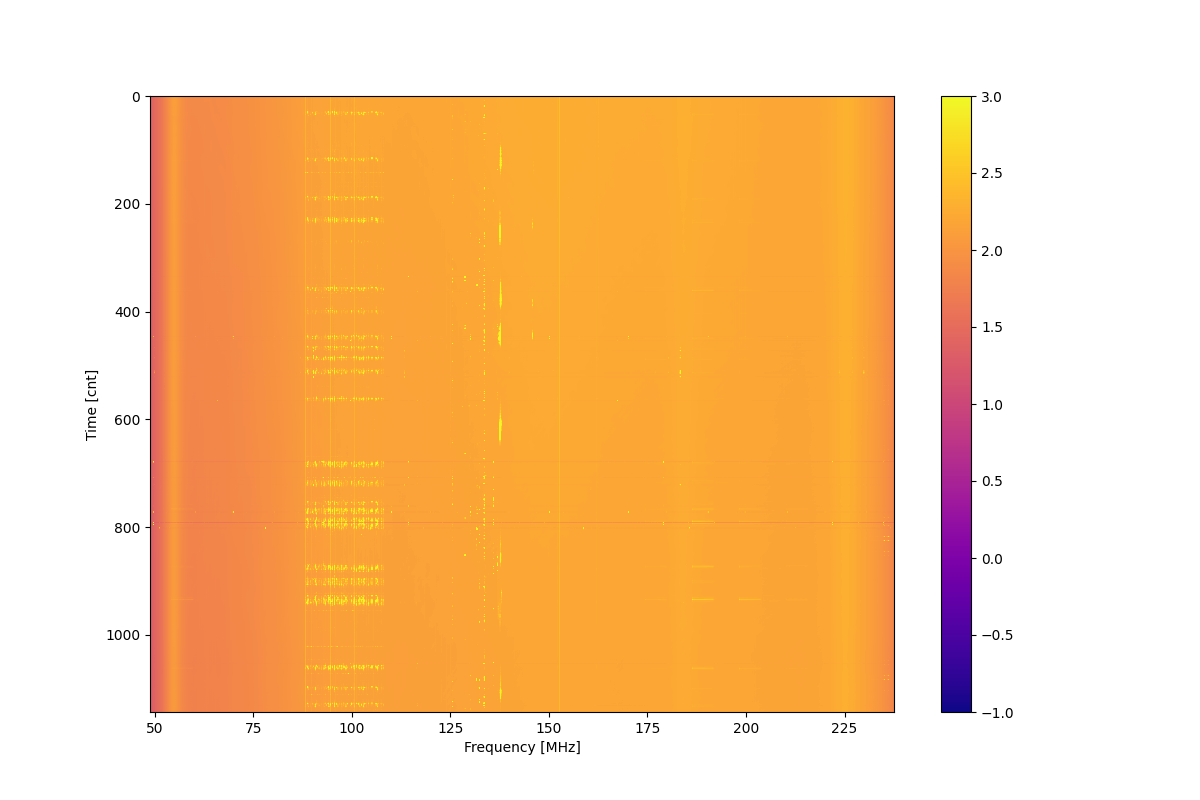

In [4]:
# raw data
wfall(davg)

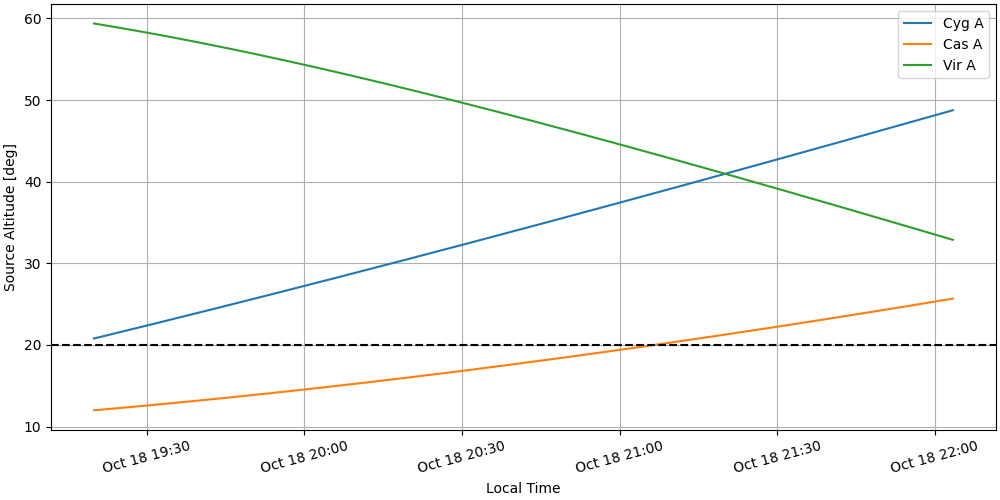

In [5]:
# location of point sources
LAT = 39.2477
LON = -113.4033

def sources(lon_deg, lat_deg, times):
    """
    lon_deg, lat_deg: observer longitude (East +) and latitude in degrees
    time: must be able to instantiate astropy.Time
    """
    loc = EarthLocation(lat=lat_deg*u.deg, lon=lon_deg*u.deg)
    obstime = Time(times)
    altaz_frame = AltAz(obstime=obstime, location=loc)

    alts = {}
    azs = {}
    for name in ["Cyg A", "Cas A", "Vir A"]:
        c = SkyCoord.from_name(name).transform_to(altaz_frame)
        alts[name] = c.alt.to(u.deg).value
        azs[name] = c.az.to(u.deg).value
    return alts, azs

alts, azs = sources(LON, LAT, dts)



plt.figure(figsize=(10, 5), constrained_layout=True)
for k, v in alts.items():
    plt.plot(dts, v, label=k)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
plt.xticks(rotation=15)
plt.grid()
plt.axhline(20, ls="--", c="k")
plt.legend()
plt.xlabel("Local Time")
plt.ylabel("Source Altitude [deg]")
plt.show()

## Flag RFI

In [6]:
def plot_spec(data, mask, model=None, noise_model=None, log=True):
    plt.figure()
    plt.plot(freq, data, label="Data")
    if model is not None:
        plt.plot(freq, model, label="Model")
        plt.plot(freq, np.abs((data - model)*mask), label="Residual")
        if noise_model is not None:
            plt.plot(freq, noise_model, label="Noise Model")
    else:
        plt.plot(freq, data * mask, label="Masked")
    if log:
        plt.yscale("log")
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

### Median Flagger

/tmp/ipykernel_169347/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


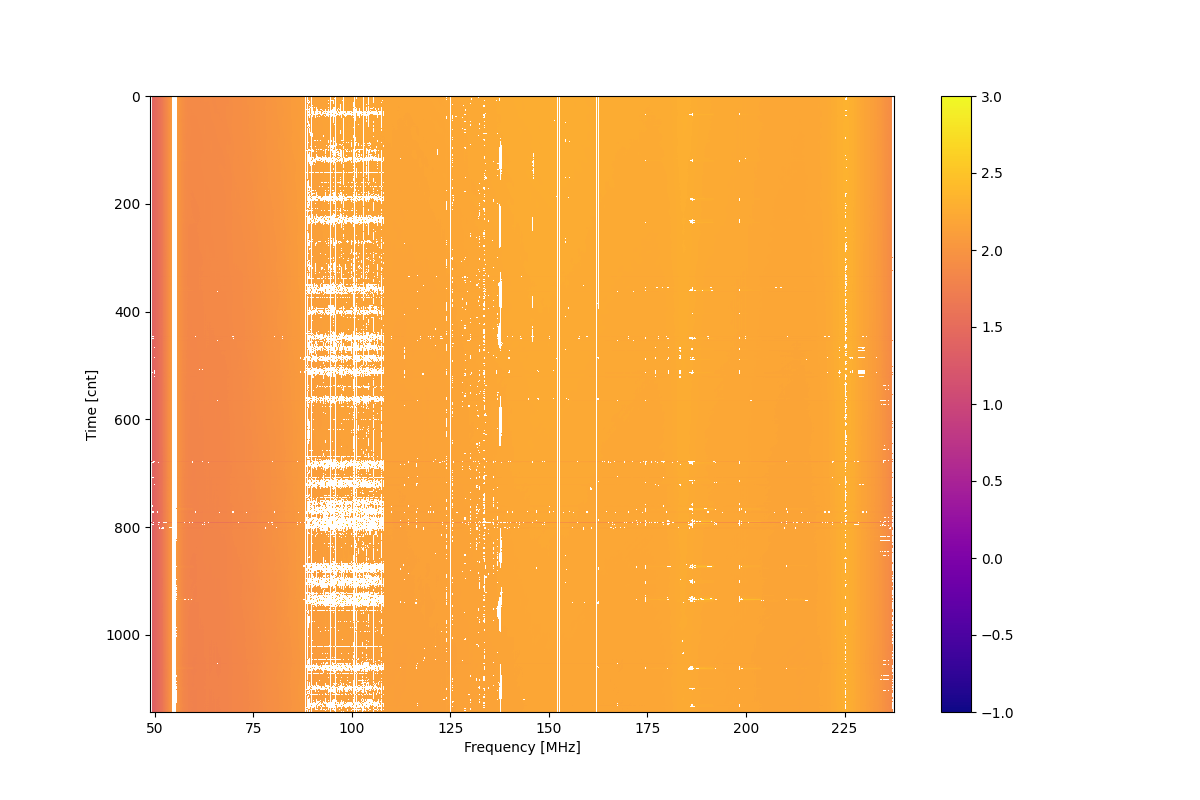

In [7]:
mad_flags, mad_z = ed.rfi.median_flagger(davg, nsig=25, kernel_half_width=5, return_z=True)
wfall(davg * ~mad_flags)

In [8]:
# noise estimate from radiometer eq
noise = davg / np.sqrt(df * dtavg)
mean_flags = ed.rfi.mean_flagger(davg, noise, nsig=15, flags=mad_flags)
mean_flags = ed.rfi.broadcast_flags(mean_flags | mad_flags)

/tmp/ipykernel_169347/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


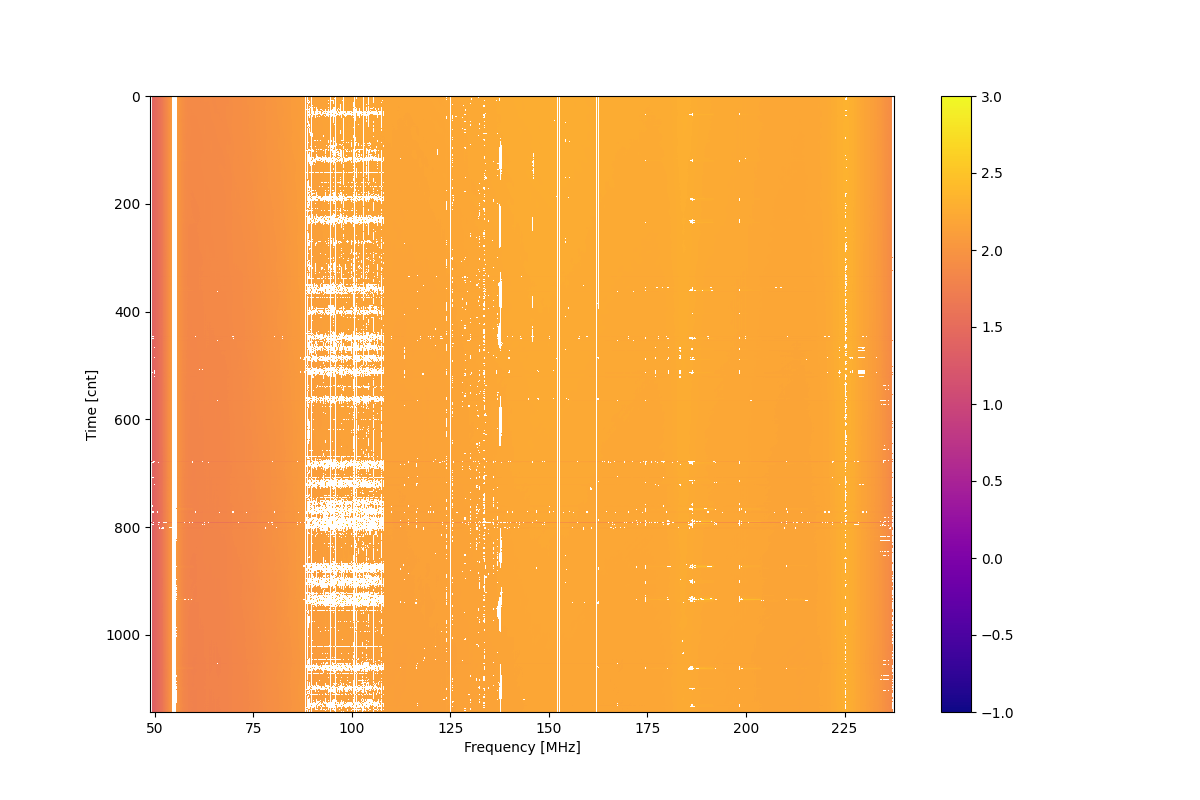

/tmp/ipykernel_169347/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


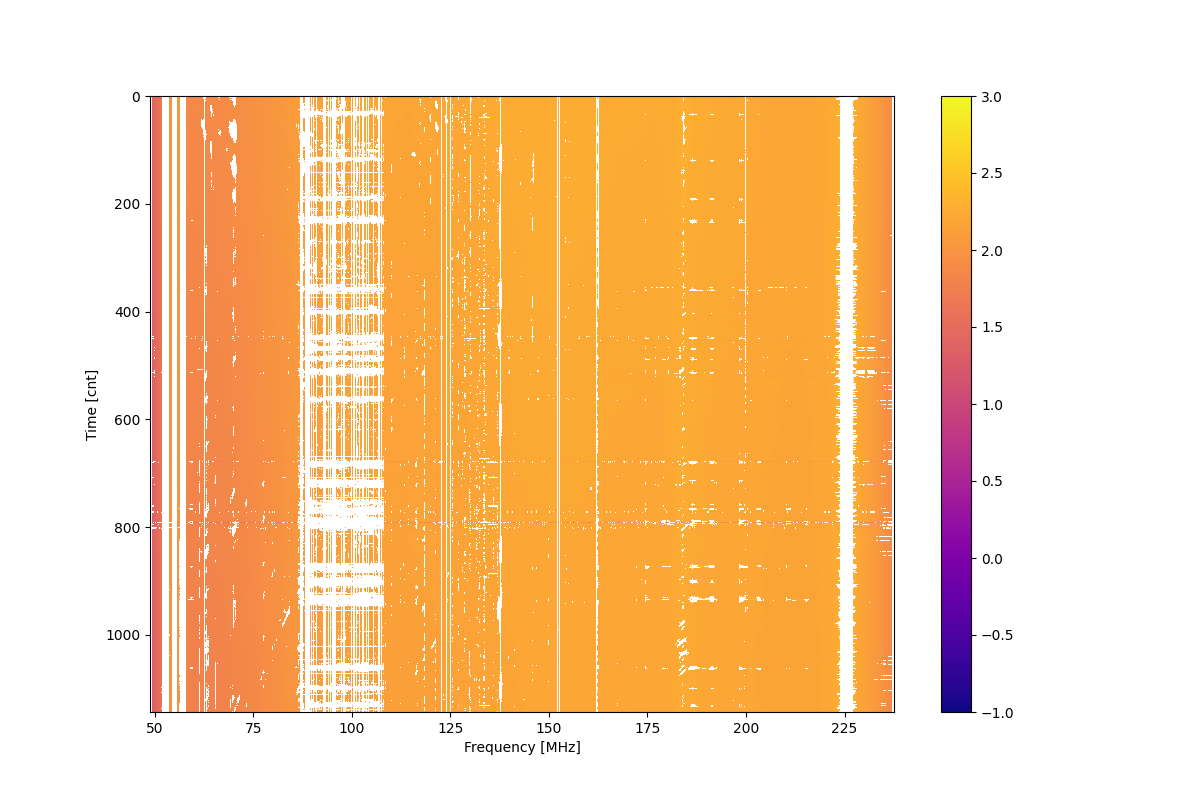

In [9]:
wfall(davg * ~mad_flags)
wfall(davg * ~mean_flags)

### 2D DPSS Model

In [10]:
from scipy.stats import median_abs_deviation

At = hera_filters.dspec.dpss_operator(tavg, [0], [3.3e-3], eigenval_cutoff=[1e-9])[0].real
Af = hera_filters.dspec.dpss_operator(freq*1e6, [0], [300e-9], eigenval_cutoff=[1e-9])[0].real
#At = hera_filters.dspec.dpss_operator(tavg, [0], [1/300], eigenval_cutoff=[1e-9])[0]
#Af = hera_filters.dspec.dpss_operator(freq*1e6, [0], [300e-9], eigenval_cutoff=[1e-9])[0]

def dpss2d(flags=np.zeros_like(davg)):
    """
    Fit a 2D DPSS model to the data.

    Parameters
    ----------
    flags : ndarray
        Array of flags. 1 indicates flagged data, 0 unflagged.

    Returns
    -------
    dmdl : ndarray
        Data model
    nmdl : ndarray
        Noise model derived from radiometer equation
    sigma : float
        Empirical noise calculated with median absolute deviation. This is a global value,
        which is only appropriate if the noise level is stable.
    
    """
    wgts = np.logical_not(flags).astype(float)
    fit, meta = hera_filters.dspec.sparse_linear_fit_2D(davg, wgts, At, Af)
    dmdl = At @ fit @ Af.T
    nmdl = dmdl / np.sqrt(df * dtavg)
    print(meta)
    res = davg - dmdl
    sigma = median_abs_deviation(res, axis=None, scale="normal")  # OK for short observation / stable noise floor
    return dmdl, nmdl, sigma

0.9337332510438779
{'istop': 2, 'iter_num': 196}
0.9200921913184624
{'istop': 2, 'iter_num': 329}
0.9132976594979891
{'istop': 2, 'iter_num': 421}
{'istop': 2, 'iter_num': 626}


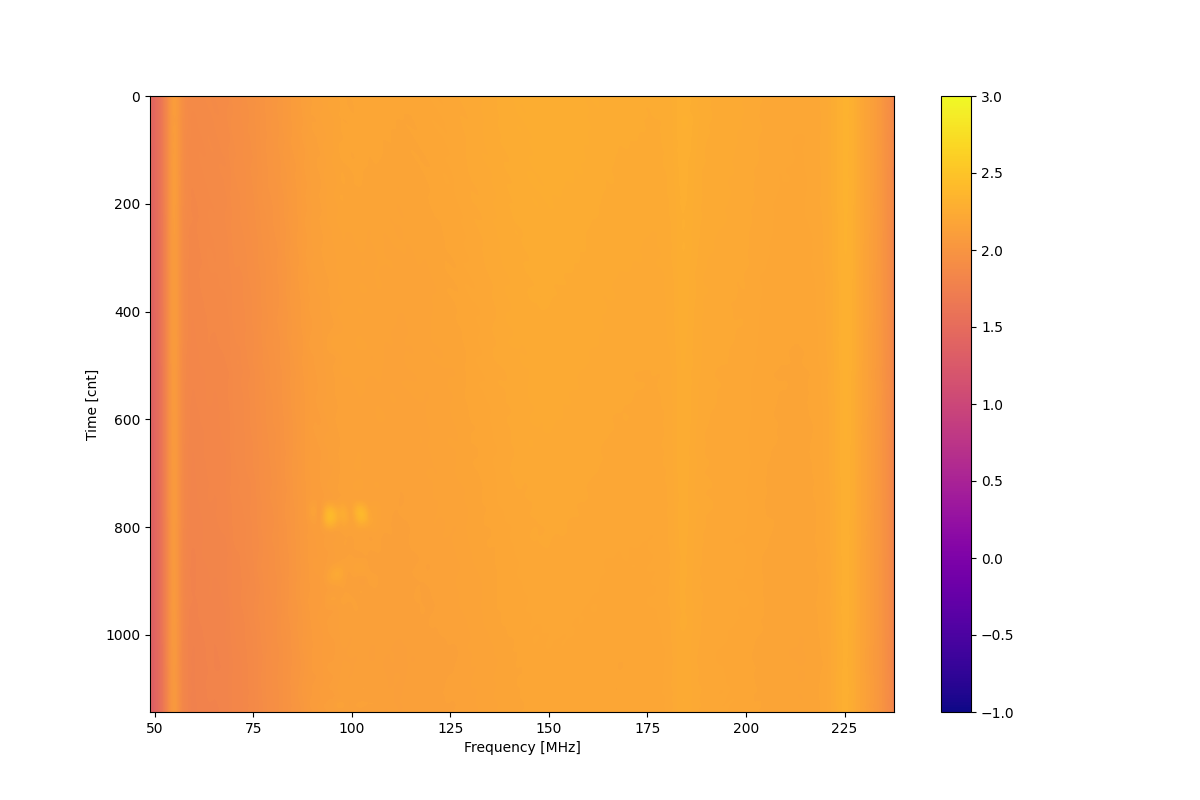

/tmp/ipykernel_169347/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


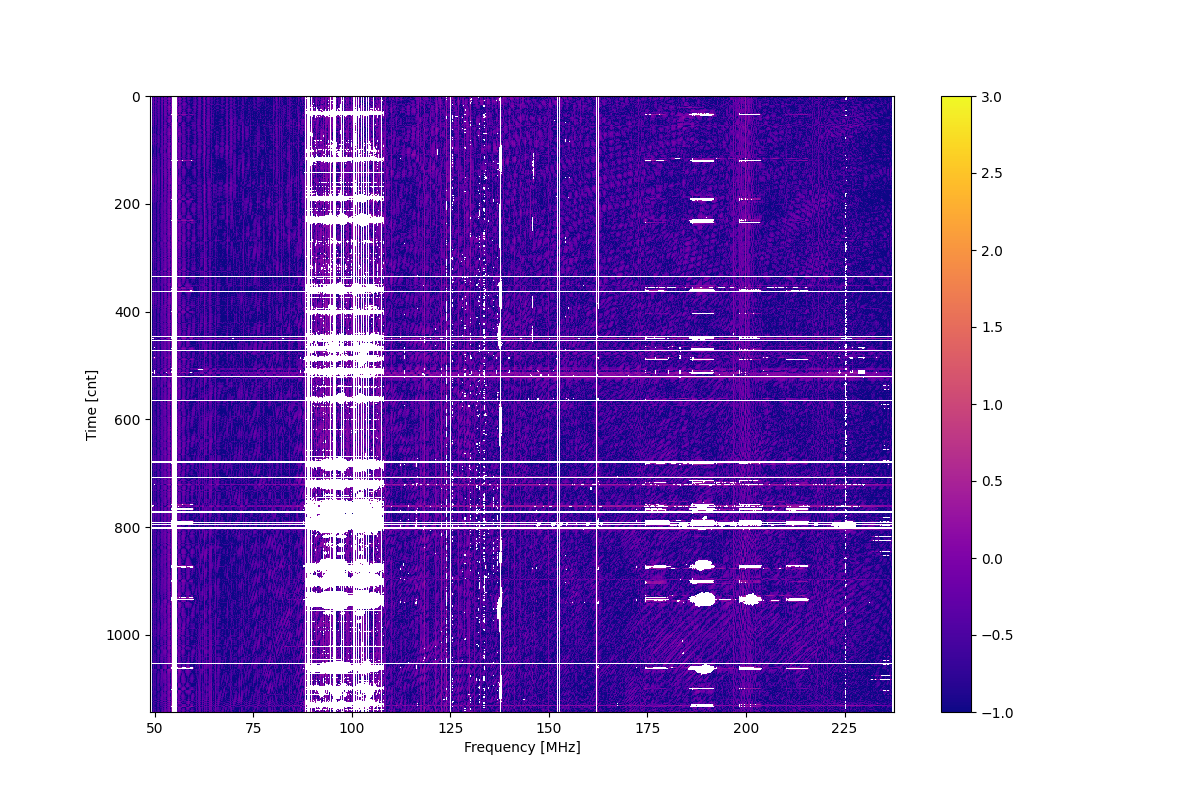

In [11]:
flags = mad_flags.copy()
for thresh in (15, 10, 5):
    print(1-np.mean(flags))
    dmdl, nmdl, sigma = dpss2d(flags)
    # flag outliers: set to 1 if outlier, otherwise default to previous
    outliers = np.abs(davg - dmdl) > thresh * sigma
    flags[outliers] = 1

# broadcast flags: flag full integration/channel if >50% is flagged
flags = ed.rfi.broadcast_flags(flags)
# final model
dmdl, nmdl, sigma = dpss2d(flags)
wfall(dmdl)
wfall((davg-dmdl)*~flags)

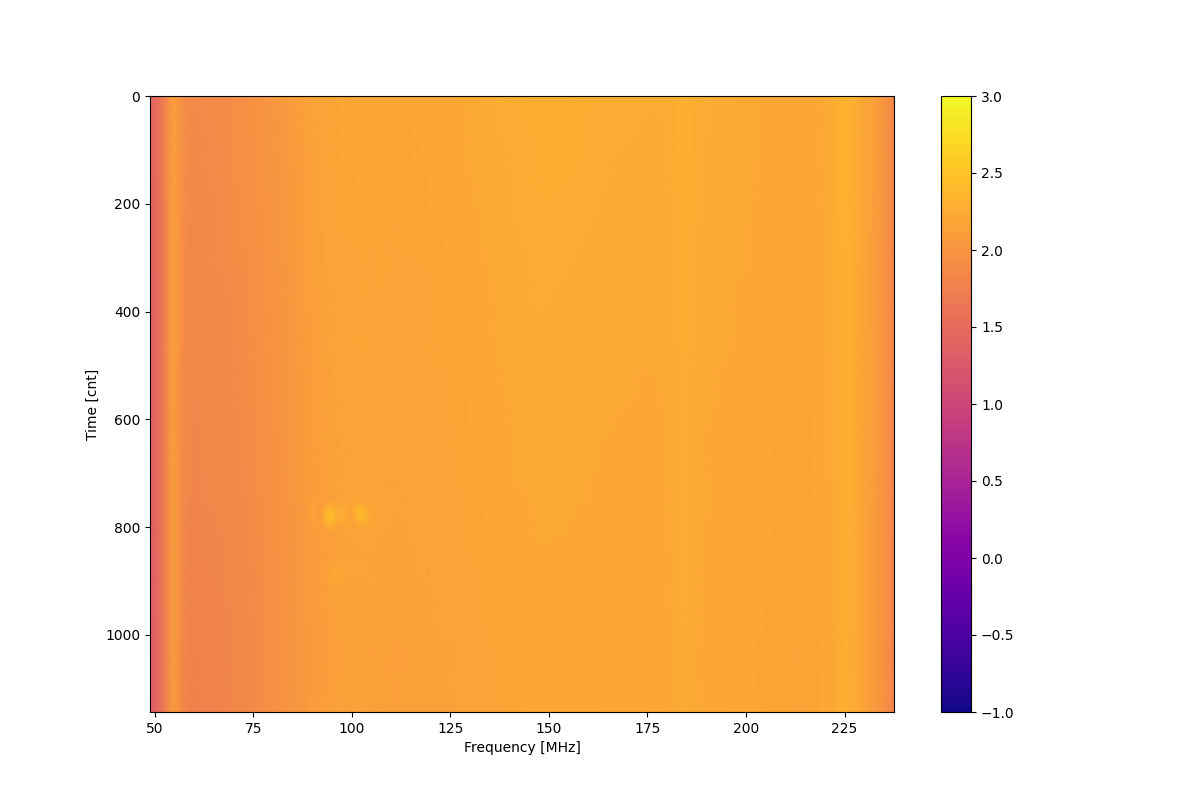

In [12]:
# inpaint
inp_noise = np.random.normal(scale=sigma, size=davg.shape)
inp = np.where(flags, dmdl+inp_noise, davg)
wfall(inp)

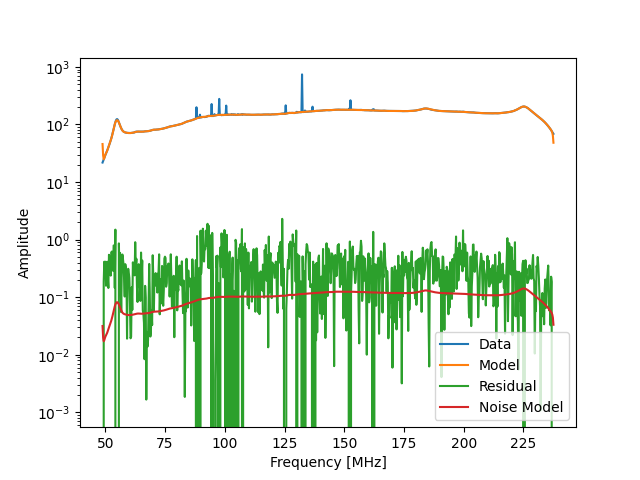

In [13]:
plot_spec(davg[300], ~flags[300], model=dmdl[300], noise_model=nmdl[300])

## Fourier transform residuals

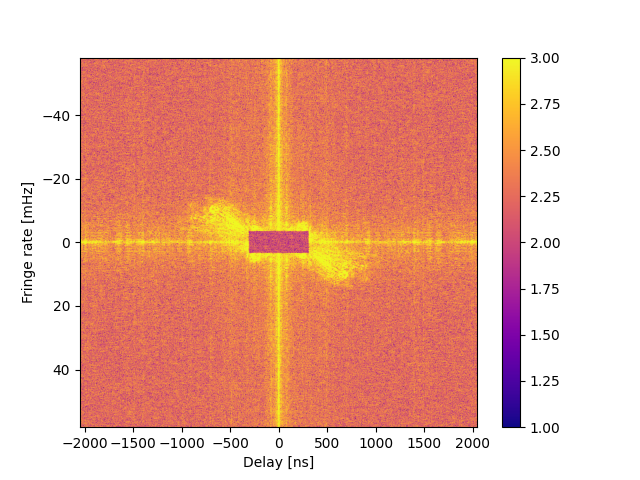

In [14]:
dly = np.fft.fftfreq(freq.size, d=df*1e-9)  # nanoseconds
fringe = np.fft.fftfreq(len(tavg), dtavg) * 1e3  # mHz
ext = [dly.min(), dly.max(), fringe.max(), fringe.min()]

plt.figure()
plt.imshow(np.fft.fftshift(np.log10(np.abs(np.fft.fft2(inp-dmdl)))), extent=ext, aspect="auto", vmin=1, vmax=3, cmap="plasma")
plt.colorbar()
plt.xlabel("Delay [ns]")
plt.ylabel("Fringe rate [mHz]")
plt.show()

## Delay transform

In [15]:
window = hera_filters.dspec.gen_window('bh7', freq.size)
_d = np.fft.fft(window[None] * (inp - dmdl), axis=1)
U, S, Vh = np.linalg.svd(_d, full_matrices=False)
# remove 3 brightest modes to filter background
_d_filt = (U * S)[:, 3:] @ Vh[3:]
dplot = np.abs(_d_filt)
#dplot = np.abs(_d)

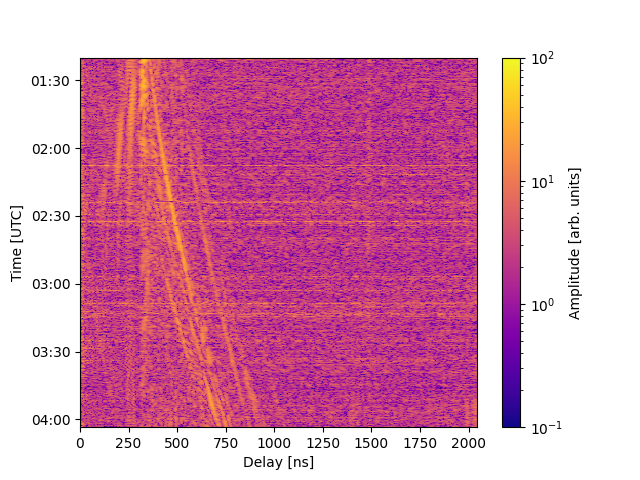

In [16]:
tstart_dt = datetime.fromtimestamp(tavg[0]+6*3600)
tend_dt = datetime.fromtimestamp(tavg[-1]+6*3600)
extent = [0, dly.max(), tend_dt, tstart_dt]

vmin = 1e-1
vmax = 1e2

plt.figure()
plt.imshow(dplot[:, dly>=0], cmap='plasma', interpolation='none', aspect='auto', extent=extent, norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.gca().yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.colorbar(label="Amplitude [arb. units]")
plt.xlabel("Delay [ns]")
plt.ylabel("Time [UTC]")
plt.show()

## Final plot: normalize by total power

In [17]:
_d = np.fft.fft(window[None] * (inp - dmdl), axis=1)
# total windowed power at each time
ptot = np.sum(inp * window[None], axis=1)

_d = _d/ptot[:, None]

U, S, Vh = np.linalg.svd(_d, full_matrices=False)
# remove 3 brightest modes to filter background
_d_filt = (U * S)[:, 3:] @ Vh[3:]
dplot = np.abs(_d_filt)
#dplot = np.abs(_d)

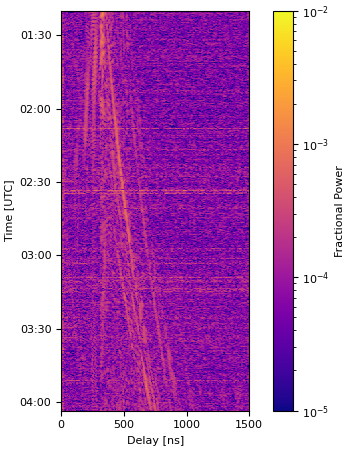

In [20]:
vmin = 1e-5
vmax = 1e-2

fontsize = 8

plt.figure(figsize=(3.5, 4.5), constrained_layout=True)
plt.imshow(dplot[:, dly>=0], cmap="plasma", interpolation='none', aspect='auto', extent=extent, norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.gca().yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
cbar = plt.colorbar()
cbar.set_label(label="Fractional Power", fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize)
plt.xlabel("Delay [ns]", fontsize=fontsize)
plt.ylabel("Time [UTC]", fontsize=fontsize)
plt.xlim(0, 1500)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
#plt.savefig("/home/christian/Downloads/point_src.pdf", bbox_inches="tight")
plt.show()